In [1]:
# Spped up sklearn for Intel Based CPUs
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


### Loading the data and checking info

In [5]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 100) 

df = pd.read_csv("../data/TelcoCustomerChurn.csv")

print("-"*100)
print('Summary Info')
print(df.info())
print("-"*100)

print("-"*100)
print("Statistical Summary")
print(df.describe())

print("-"*100)
print("Statistical Summary Catagorical Columns")
print(df.describe(include=['object']))


----------------------------------------------------------------------------------------------------
Summary Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043

### Missing Value Analysis

There is no missing values so Impoutations are not required

In [6]:
#missing count per column
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Duplicate Analysis
There are no duplicates so no removal required

### Numerical and Categorical Feature Identification
SeniorCitizen is being identified as int. we will need to manually consider this in categorical columns

In [7]:
print("-"*100)
print("Duplicated Data")
print(df.duplicated().sum())


numberical_columns = df.select_dtypes(include= ['int64', 'float64']).columns.to_list()
categorical_columns = df.select_dtypes(include= ['string', 'object', 'category']).columns.to_list()
print("-"*100)
print("Numerical Columns")
print(numberical_columns)
print("-"*100)
print("Categorical Columns")
print(categorical_columns)

----------------------------------------------------------------------------------------------------
Duplicated Data
0
----------------------------------------------------------------------------------------------------
Numerical Columns
['SeniorCitizen', 'tenure', 'MonthlyCharges']
----------------------------------------------------------------------------------------------------
Categorical Columns
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


### Target Variable Analysis

----------------------------------------------------------------------------------------------------
count     7043
unique       2
top         No
freq      5174
Name: Churn, dtype: object
----------------------------------------------------------------------------------------------------
Churn
No     5174
Yes    1869
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------


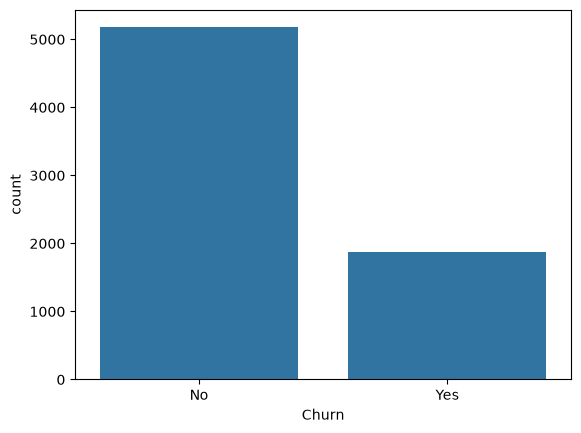

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
print("-"*100)
target = "Churn"
print(df[target].describe())
print("-"*100)
print(df[target].value_counts())
# Class distribution %
print("-"*100)
print(df[target].value_counts(normalize=True) * 100)
print("-"*100)
sns.countplot(x=df[target])
plt.show()

### EDA Analysis and Further Actions

1. The CustomerID columns is unique indetifiers which will not help in model traning so remove it.
2. TotalCharges columns is coming as str,covert that into float.
3. Full null values of TotalCharges columns with 0.0
4. Change Target variable "Churn" into 0 and 1

In [9]:
# remove customerID as it is arbitrary data
df = df.drop(columns=['customerID'], errors= 'ignore')

#the MonthlyCharger is float64 but not the TotalCharges, so convert this variable to float
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'], errors='coerce') # handling blank spaces also

# TotalCHarges also have null values
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

#change tarager variable to o and 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No' : 0})

df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### Split data into traning and testing with 0.30 split



In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
Y = df['Churn']

#maintain same class balances across splits
X_train, X_test, Y_train, Y_test  = train_test_split(
    X, Y, test_size = 0.30, random_state = 42, stratify= Y)

print("-"*100)
print(f"Traning set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("-"*100)


----------------------------------------------------------------------------------------------------
Traning set size: (4930, 19)
Testing set size: (2113, 19)
----------------------------------------------------------------------------------------------------


### Exploratory Data Anlysis
Create plots to understand the data and distribution

### Insights from the Plots

- Month-to-moth contracts have heigher churn rate, about 40 pervent
- Tenure less than 6 months have high churn rate
- Higher median MonthlyCharges (~$80) correlate with churned users.

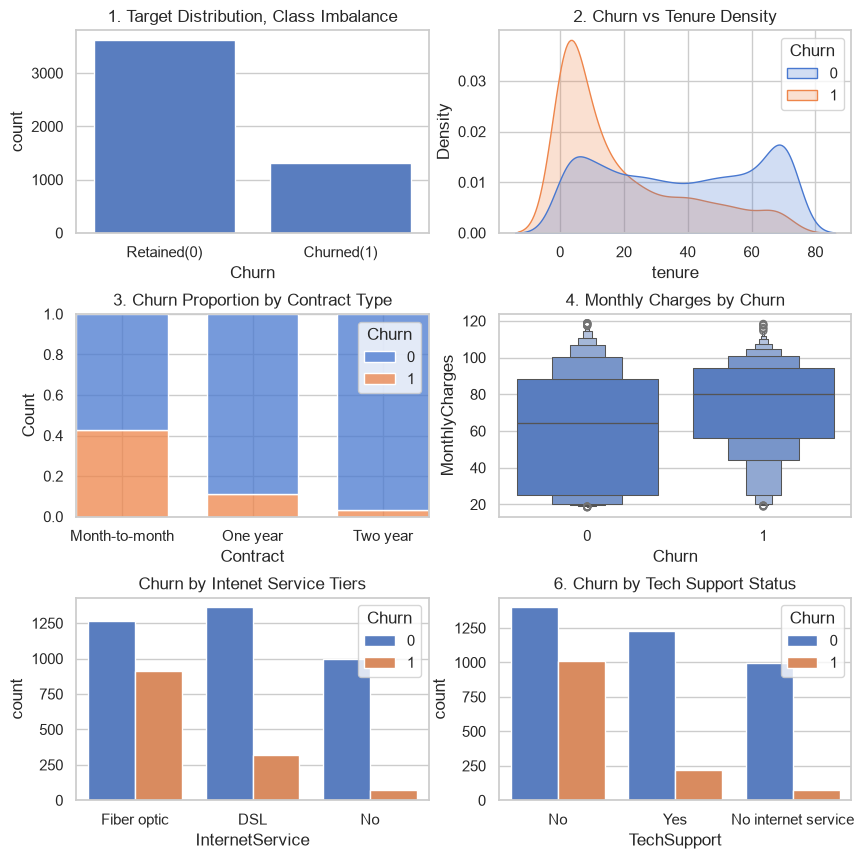

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme(style="whitegrid", palette="muted")
fig , axes = plt.subplots(3,2, figsize = (10,10))
plt.subplots_adjust(hspace=0.4)

#run EDA on X_train
eda_df = X_train.copy()
eda_df["Churn"] = Y_train
# BAR PLOT Churn Distribution
sns.countplot(data = eda_df, x='Churn', ax=axes[0,0])
axes[0,0].set_title("1. Target Distribution, Class Imbalance")
axes[0, 0].set_xticks([0, 1])
axes[0,0].set_xticklabels((["Retained(0)", "Churned(1)"]))

#TENURE KDE PLOT
sns.kdeplot(data=eda_df, x="tenure", hue="Churn", fill = True, common_norm = False, ax= axes[0][1])
axes[0][1].set_title("2. Churn vs Tenure Density")

#Historgram for Churn Probability by Contract Type
sns.histplot(data= eda_df, x = "Contract", hue="Churn", multiple='fill', shrink=0.7, ax = axes[1][0])
axes[1][0].set_title("3. Churn Proportion by Contract Type")

# Monthly Charges boxenplot
sns.boxenplot(data=eda_df, x='Churn', y='MonthlyCharges', ax=axes[1][1])
axes[1][1].set_title("4. Monthly Charges by Churn")

# Internet Service vs Chrun
sns.countplot(data=eda_df, x="InternetService", hue="Churn", ax = axes[2][0])
axes[2][0].set_title("Churn by Intenet Service Tiers")

# Chart 6: Tech Support vs Churn
sns.countplot(data=eda_df, x='TechSupport', hue='Churn', ax=axes[2, 1])
axes[2, 1].set_title('6. Churn by Tech Support Status')

plt.show()

### 1. Target Distribution, Class Imbalance
- More retained customers than churned customers
- Churn rate around 25-30%
- Moderate class imbalance present
- Accuracy alone may not be sufficient for evaluation

### 2. Churn vs Tenure Density
- Churned customers concentrated at lower tenure values
- Long-tenure customers less likely to churn
- Customer loyalty increases with tenure
- Tenure is a strong churn predictor

### 3. Churn Proportion by Contract Type
- Month-to-month contract has highest churn rate
- One-year contract has significantly lower churn
- Two-year contract has the lowest churn rate
- Contract type is one of the strongest churn drivers

### 4. Monthly Charges by Churn
- Churned customers generally have higher monthly charges
- Retained customers show lower median charges
- Higher monthly cost associated with increased churn risk

### 5. Churn by Internet Service Type
- Fiber optic customers show the highest churn
- DSL customers have lower churn than Fiber optic
- Customers without internet service rarely churn
- Internet service type impacts retention

### 6. Churn by Tech Support Status
- Customers without Tech Support have highest churn
- Customers with Tech Support have much lower churn
- Customers without internet service show very low churn
- Tech Support appears to improve customer retention

### Overall Findings
- High-risk customers:
  - Low tenure
  - Month-to-month contracts
  - High monthly charges
  - Fiber optic service
  - No Tech Support

- Low-risk customers:
  - Long tenure
  - One-year or two-year contracts
  - Lower monthly charges
  - Tech Support enabled

### 3. Feature Enginnering

Feature Explanations:
Service_Count (Numerical):

Use: Sums up the number of active add-on features a customer has (e.g., OnlineSecurity, TechSupport, StreamingTV).
Reason: It measures ecosystem stickiness. A customer with 5 integrated services has a much higher "switching cost" to move to a competitor than a customer who only buys raw internet. The model can use this to identify vulnerable bare-bones accounts.

Avg_Monthly_Charge (Numerical):

Use: Calculated by dividing TotalCharges by tenure. (Fallback to MonthlyCharges if tenure is 0 to avoid division by zero).
Reason: It acts as a proxy for billing consistency. If a customer's current MonthlyCharges is significantly higher than their Avg_Monthly_Charge, it indicates their promotional rate expired or they were recently hit with a price hike—a massive trigger for immediate churn.

In [12]:
# Add new feature with number of add on service count.
def apply_feaure_enginnering(df:pd.DataFrame) -> pd.DataFrame:
    out_df = df.copy()

    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
    out_df["Service_Count"] = out_df[service_cols].apply(lambda x: (x == "Yes").sum(), axis = 1)

    out_df["Average_Monthly_Charges"] = np.where(
        out_df["tenure"] > 0,
        out_df["TotalCharges"] / out_df["tenure"],
        out_df["MonthlyCharges"]
    )
    return out_df

X_train = apply_feaure_enginnering(X_train)
X_test = apply_feaure_enginnering(X_test)

X_train[['Service_Count', 'Average_Monthly_Charges', 'MonthlyCharges']].head()

,Service_Count,Average_Monthly_Charges,MonthlyCharges
5557,1,76.850000,80.20
2270,2,73.650000,86.85
6930,0,72.250000,75.15
2257,4,80.784167,80.55
898,4,93.412500,98.90


### Convert Categaorical data to Numbers
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder 

----------------------------------------------------------------------------------------------------
Numerical Columns
['tenure', 'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Average_Monthly_Charges']
----------------------------------------------------------------------------------------------------
Categorical Columns
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
{'gender': ['Female', 'Male'], 'SeniorCitizen': [0, 1], 'Partner': ['No', 'Yes'], 'Dependents': ['No', 'Yes'], 'PhoneService': ['Yes', 'No'], 'MultipleLines': ['No', 'Yes', 'No phone service'], 'InternetService': ['Fiber optic', 'DSL', 'No'], 'OnlineSecurity': ['No', 'Yes', 'No internet service'], 'OnlineBackup': ['No', 'No internet service', 'Yes'], 'DeviceProtection': ['No', 'Yes', 'No internet service'], 'Te

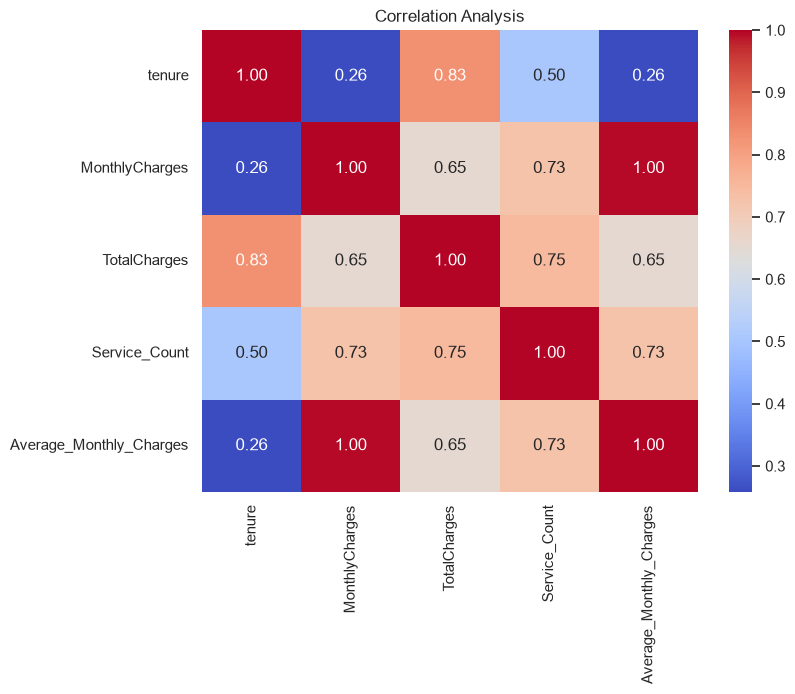

Corelation with target
Churn                      1.000000
MonthlyCharges             0.199737
Average_Monthly_Charges    0.199044
Service_Count             -0.081973
TotalCharges              -0.190210
tenure                    -0.343520
Name: Churn, dtype: float64
----------------------------------------------------------------------------------------------------
Corelation with Categorical Variable
gender
Male      26.76
Female    26.31
Name: 1, dtype: float64


SeniorCitizen
1    41.06
0    23.74
Name: 1, dtype: float64


Partner
No     32.92
Yes    19.65
Name: 1, dtype: float64


Dependents
No     31.48
Yes    14.86
Name: 1, dtype: float64


PhoneService
Yes    26.88
No     23.39
Name: 1, dtype: float64


MultipleLines
Yes                 28.94
No                  25.05
No phone service    23.39
Name: 1, dtype: float64


InternetService
Fiber optic    41.85
DSL            19.17
No              6.93
Name: 1, dtype: float64


OnlineSecurity
No                     42.03
Yes          

,Feature,Chi2,PValue
22,Contract_Two year,338.039468,1.705467e-75
25,PaymentMethod_Electronic check,310.058332,2.120887e-69
7,InternetService_Fiber optic,261.961754,6.410719e-59
13,DeviceProtection_No internet service,210.540820,1.046827e-47
15,TechSupport_No internet service,210.540820,1.046827e-47
19,StreamingMovies_No internet service,210.540820,1.046827e-47
17,StreamingTV_No internet service,210.540820,1.046827e-47
8,InternetService_No,210.540820,1.046827e-47
11,OnlineBackup_No internet service,210.540820,1.046827e-47
9,OnlineSecurity_No internet service,210.540820,1.046827e-47


In [13]:
numerical_columns = ["tenure", "MonthlyCharges", "TotalCharges", "Service_Count", "Average_Monthly_Charges"]
categorical_columns = [col for col in X_train.columns if col not in numerical_columns]

print("-"*100)
print("Numerical Columns")
print(numerical_columns)
print("-"*100)
print("Categorical Columns")
print(categorical_columns)
unique_values = {
    col: X_train[col].unique().tolist()
    for col in categorical_columns
}
print(unique_values)


corr_df = X_train.copy()
corr_df["Churn"] = Y_train

# Corelation of Numerical Data
corr_matrix = corr_df[numerical_columns].corr()
plt.figure(figsize =(8,6))
sns.heatmap(
    corr_matrix,
    annot= True,
    cmap= "coolwarm",
    fmt=".2f"
)
print("-"*100)
plt.title("Correlation Analysis")
plt.show()

#corelation with Churn
corr_with_churn= (
    corr_df[numerical_columns + ["Churn"]].corr()["Churn"].sort_values(ascending= False)
) 
print("Corelation with target")
print(corr_with_churn)

print("-"*100)
print("Corelation with Categorical Variable")
for col in categorical_columns:
    churn_rate = (
        pd.crosstab(
            corr_df[col],
            corr_df["Churn"],
            normalize="index"
        )[1] * 100
    ).round(2)

    print(churn_rate.sort_values(ascending=False))
    print("\n")
print("-"*100)


#Check Multicoliniary with VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = corr_df[numerical_columns]

vif_df = pd.DataFrame()
vif_df["Feature"] = X_num.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_num.values, i)
    for i in range(X_num.shape[1])
]
print("VIF")
print(vif_df.sort_values("VIF", ascending=False))

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

X_cat = pd.get_dummies(
    corr_df[categorical_columns],
    drop_first=True
)

y = corr_df["Churn"]


chi_scores, p_values = chi2(X_cat, y)

chi_df = pd.DataFrame({
    "Feature": X_cat.columns,
    "Chi2": chi_scores,
    "PValue": p_values
})

chi_df.sort_values(
    "Chi2",
    ascending=False
).head(20)


### Summary

- churn is mainly influenced by **contract type, payment method, internet services, tenure, and monthly charges**.

- Customers on **month-to-month contracts** have the highest churn rate (42.9%), while customers on **two-year contracts** rarely churn (3.0%). This suggests that long-term contracts significantly improve retention.

- **Electronic Check** show the highest churn rate (45.7%), 

- Customers using **Fiber Optic** internet and those without **Online Security** or **Tech Support** are considerably more likely to churn.

- Among numerical features, **tenure** is the strongest predictor. Customers who have stayed longer with the company are less likely to churn.

- **MonthlyCharges** shows a positive relationship with churn, indicating that customers with higher monthly bills are more likely to leave.

- Chi-Square analysis confirmed that **Contract, PaymentMethod, InternetService, OnlineSecurity, TechSupport, Dependents, and SeniorCitizen** are the most influential categorical features.

- Multicollinearity analysis identified redundancy between **MonthlyCharges** and **Average_Monthly_Charges**, while **TotalCharges** was found to be highly related to **tenure**.

### Feature Selection

- Remove: `Average_Monthly_Charges`

### Key Takeaway

Customers most likely to churn are typically those with **short tenure, higher monthly charges, month-to-month contracts, electronic check payments, fiber-optic services, and no security or support add-ons**.

In [14]:
def apply_final_feaure_enginnering(df:pd.DataFrame) -> pd.DataFrame:
    out_df = df.copy()
    out_df.drop(columns=["Average_Monthly_Charges"], inplace=True, errors="ignore")
    out_df["AutoPayment"] = (
    out_df["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
        ])
        ).astype(int)

    out_df["FamilyCustomer"] = (
        (df["Partner"] == "Yes") |
        (df["Dependents"] == "Yes")
        ).astype(int)

    # Customer Lifecycle Stage
    out_df["CustomerType"] = pd.cut(
        out_df["tenure"],
        bins=[-1, 12, 36, float("inf")],
        labels=["New", "Regular", "Loyal"]
    )

    # Count of support-related services
    support_cols = ["OnlineSecurity",
                    "OnlineBackup",
                    "DeviceProtection",
                    "TechSupport",
                    ]
    out_df["Support_Count"] = out_df[support_cols].apply(
    lambda row: (row == "Yes").sum(),
    axis=1)
    
    return out_df

    
X_train = apply_final_feaure_enginnering(X_train)
X_test = apply_final_feaure_enginnering(X_test)
print(X_train.columns)


numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Service_Count",
    "Support_Count"
]
categorical_columns = [col for col in X_train.columns if col not in numerical_columns]

print("-"*100)
print("Numerical Columns")
print(numerical_columns)
print("-"*100)
print("Categorical Columns")
print(categorical_columns)

X_train

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Service_Count', 'AutoPayment',
       'FamilyCustomer', 'CustomerType', 'Support_Count'],
      dtype='object')
----------------------------------------------------------------------------------------------------
Numerical Columns
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Support_Count']
----------------------------------------------------------------------------------------------------
Categorical Columns
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBil

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Service_Count,AutoPayment,FamilyCustomer,CustomerType,Support_Count
5557,Female,0,No,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,80.20,384.25,1,0,0,New,0
2270,Female,1,No,No,3,Yes,No,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,86.85,220.95,2,0,0,New,1
6930,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,0,1,1,New,0
2257,Female,0,No,No,60,Yes,Yes,DSL,No,No,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.55,4847.05,4,1,0,Loyal,2
898,Female,0,No,No,12,Yes,No,Fiber optic,Yes,No,No,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),98.90,1120.95,4,1,0,New,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4250,Male,0,No,No,63,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,No,One year,No,Credit card (automatic),104.50,6590.80,5,1,0,Loyal,4
1488,Male,0,No,No,1,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,51.25,51.25,1,0,0,New,1
6303,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.25,7707.70,5,0,1,Loyal,3
2710,Female,0,Yes,No,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.40,482.80,0,1,1,Regular,0


### Prepare Pipiline of Transformation and Scaling to apply it only on Training data to prevent data leakage

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown= 'ignore'), categorical_columns)
    ]
)

print("preprocessor Configured")

preprocessor Configured


## Model Training

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

decision_tree_simple  = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

decision_tree_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf = 10,
        class_weight='balanced',
        random_state = 42
    ))
])

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

decision_tree_GridCV  = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid = {
'classifier__max_depth': [3, 5, 10, 20, 30, None],
'classifier__min_samples_split': [2, 3, 4, 5, 8, 10],
'classifier__min_samples_leaf': [1, 2, 3, 4, 5],
}

grid_search = GridSearchCV(
    estimator = decision_tree_GridCV,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=3,
    scoring='f1' # or f1, roc_auc, etc.
)

In [17]:
print("Training Simple Decision Tree")
decision_tree_simple.fit(X_train, Y_train)

print("Training Balanced Decision Tree")
decision_tree_balanced.fit(X_train, Y_train)

print("Training Grid Search CV Decision Tree")
grid_search.fit(X_train, Y_train)
decision_tree_bestGridCV = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Training Simple Decision Tree
Training Balanced Decision Tree
Training Grid Search CV Decision Tree
Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
Best CV Score: 0.5678406062282355


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Unpruned Tree": decision_tree_simple,
    "Pruned and Balanced Tree": decision_tree_balanced,
    "Best GridSearchCV Tree": decision_tree_bestGridCV
}

for name, model in models.items():

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("-" * 100)
    print(name)

    print(f"Train Accuracy : {accuracy_score(Y_train, y_pred_train):.4f}")
    print(f"Test Accuracy  : {accuracy_score(Y_test, y_pred_test):.4f}")

    print(f"Precision      : {precision_score(Y_test, y_pred_test):.4f}")
    print(f"Recall         : {recall_score(Y_test, y_pred_test):.4f}")
    print(f"F1 Score       : {f1_score(Y_test, y_pred_test):.4f}")

----------------------------------------------------------------------------------------------------
Unpruned Tree
Train Accuracy : 0.9980
Test Accuracy  : 0.7317
Precision      : 0.4947
Recall         : 0.4973
F1 Score       : 0.4960
----------------------------------------------------------------------------------------------------
Pruned and Balanced Tree
Train Accuracy : 0.7331
Test Accuracy  : 0.7113
Precision      : 0.4741
Recall         : 0.7986
F1 Score       : 0.5950
----------------------------------------------------------------------------------------------------
Best GridSearchCV Tree
Train Accuracy : 0.8018
Test Accuracy  : 0.7941
Precision      : 0.6145
Recall         : 0.6025
F1 Score       : 0.6085


--- Model Performance Metrics decision_tree_bestGridCV ---
Accuracy:  0.7941
Precision: 0.6145
Recall:    0.6025
F1 Score:  0.6085


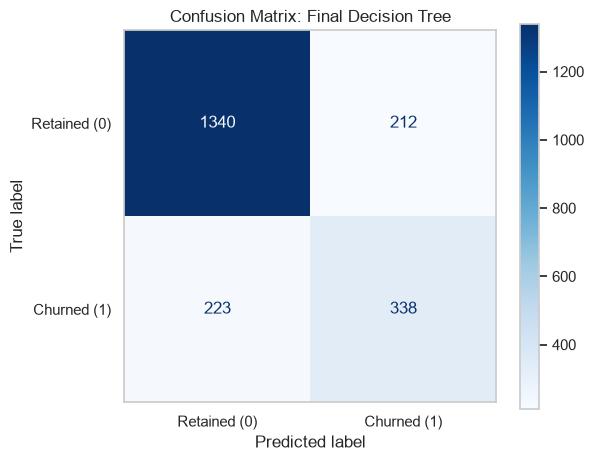

In [19]:
# Cell 11: Compute Detailed Evaluation Metrics & Confusion Matrix
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# Generate predictions on the test set using our final model (Config 2)
y_pred = decision_tree_bestGridCV.predict(X_test)

# Calculate key performance indicators
acc = accuracy_score(Y_test, y_pred)
prec = precision_score(Y_test, y_pred)
rec = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)

print("--- Model Performance Metrics decision_tree_bestGridCV ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained (0)', 'Churned (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Final Decision Tree')
plt.grid(False)
plt.show()

In [20]:
import joblib

joblib.dump(decision_tree_bestGridCV, "../model/churn_model.pkl")

['../model/churn_model.pkl']

### BONUS

Train and compare a broad set of additional classifiers beyond the baseline Decision Tree, to see whether other algorithms can better capture the churn patterns.

- **Logistic Regression / Ridge / SGD**: Fast linear baselines. Good interpretability, useful to confirm if the problem is largely linearly separable.
- **Linear SVM / RBF SVM**: Margin-based classifiers. RBF kernel captures non-linear boundaries that linear models miss.
- **Random Forest / Extra Trees**: Bagged tree ensembles that reduce overfitting compared to a single Decision Tree and handle mixed categorical/numerical features well.
- **Gradient Boosting / HistGradient Boosting / AdaBoost**: Boosted tree ensembles that iteratively correct errors, often achieving stronger predictive performance on tabular data like this.
- **K-Nearest Neighbors**: Instance-based method, useful as a non-parametric comparison point.
- **Gaussian Naive Bayes**: Simple probabilistic baseline, fast to train, useful sanity check despite its independence assumption.
- **Linear/Quadratic Discriminant Analysis**: Classical generative classifiers that model class-conditional distributions, offering another linear/non-linear comparison.
- **Neural Network (MLP)**: Captures complex non-linear interactions between features that tree/linear models might miss.
- **Voting Classifier**: Combines Logistic Regression, Random Forest, and SVM predictions to leverage diverse model strengths.
- **Stacking Classifier**: Uses predictions from Logistic Regression, Random Forest, and KNN as inputs to a meta Logistic Regression model, potentially improving on any single base model.

Each model is wrapped in a full preprocessing + classifier pipeline and tuned via `GridSearchCV` with 5-fold stratified cross-validation, optimizing for F1 score (important given the class imbalance in churn data). Results are then compared against the Decision Tree models to identify the best overall performer.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Service_Count",
    "Support_Count"
]
categorical_columns = [col for col in X_train.columns if col not in numerical_columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_columns)
    ]
)

dense_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), categorical_columns)
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

voting_classifier = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)),
        ("svm", SVC(probability=True, random_state=42))
    ],
    voting="soft",
    n_jobs=-1
)

stacking_classifier = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=7))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_jobs=-1
)

# models: name -> (estimator, use_dense_preprocessor)
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), False),
    "Linear SVM": (LinearSVC(max_iter=5000, random_state=42), False),
    "RBF SVM": (SVC(random_state=42), False),
    "Random Forest": (RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42), False),
    "Extra Trees": (ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), True),
    "HistGradient Boosting": (HistGradientBoostingClassifier(random_state=42), True),
    "AdaBoost": (AdaBoostClassifier(random_state=42), True),
    "K-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=7), True),
    "Gaussian Naive Bayes": (GaussianNB(), True),
    "Ridge Classifier": (RidgeClassifier(), False),
    "SGD Classifier": (SGDClassifier(loss="log_loss", random_state=42), False),
    "Linear Discriminant Analysis": (LinearDiscriminantAnalysis(), True),
    "Quadratic Discriminant Analysis": (QuadraticDiscriminantAnalysis(reg_param=0.1), True),
    "Neural Network": (MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=2000, early_stopping=True, random_state=42), False),
    "Voting Classifier": (voting_classifier, True),
    "Stacking Classifier": (stacking_classifier, True)
}

# param_grids: name -> hyperparameter grid for GridSearchCV (using 'classifier__' prefix)
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"]
    },
    "Linear SVM": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"]
    },
    "RBF SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", "auto", 0.01, 0.1]
    },
    "Random Forest": {
        "classifier__n_estimators": [200, 400],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_leaf": [1, 3, 5],
        "classifier__class_weight": [None, "balanced"]
    },
    "Extra Trees": {
        "classifier__n_estimators": [200, 400],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_leaf": [1, 3, 5],
        "classifier__class_weight": [None, "balanced"]
    },
    "Gradient Boosting": {
        "classifier__n_estimators": [100, 200],
        "classifier__learning_rate": [0.01, 0.1, 0.2],
        "classifier__max_depth": [2, 3, 5]
    },
    "HistGradient Boosting": {
        "classifier__learning_rate": [0.01, 0.1, 0.2],
        "classifier__max_leaf_nodes": [15, 31, 63],
        "classifier__l2_regularization": [0.0, 0.1, 1.0]
    },
    "AdaBoost": {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__learning_rate": [0.01, 0.1, 1.0]
    },
    "K-Nearest Neighbors": {
        "classifier__n_neighbors": [3, 5, 7, 9],
        "classifier__weights": ["uniform", "distance"],
        "classifier__p": [1, 2]
    },
    "Gaussian Naive Bayes": {
        "classifier__var_smoothing": [1e-9, 1e-8, 1e-7]
    },
    "Ridge Classifier": {
        "classifier__alpha": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"]
    },
    "SGD Classifier": {
        "classifier__alpha": [1e-4, 1e-3, 1e-2],
        "classifier__penalty": ["l2", "l1", "elasticnet"],
        "classifier__class_weight": [None, "balanced"]
    },
    "Linear Discriminant Analysis": {
        "classifier__solver": ["svd", "lsqr"]
    },
    "Quadratic Discriminant Analysis": {
        "classifier__reg_param": [0.1, 0.3, 0.5, 0.9]
    },
    "Neural Network": {
        "classifier__hidden_layer_sizes": [(50, 25), (100,), (50, 50)],
        "classifier__alpha": [1e-4, 1e-3],
        "classifier__learning_rate_init": [1e-3, 1e-2]
    },
    "Voting Classifier": {
        "classifier__lr__C": [0.1, 1, 10],
        "classifier__rf__max_depth": [None, 10, 20],
        "classifier__svm__C": [0.1, 1, 10]
    },
    "Stacking Classifier": {
        "classifier__lr__C": [0.1, 1, 10],
        "classifier__rf__max_depth": [None, 10, 20],
        "classifier__knn__n_neighbors": [3, 5, 7],
        "classifier__final_estimator__C": [0.1, 1, 10]
    }
}

# grid_searches: name -> GridSearchCV configured with the correct preprocessor
grid_searches = {}
for name, (estimator, use_dense) in models.items():
    chosen_preprocessor = dense_preprocessor if use_dense else preprocessor
    pipeline = Pipeline(
        steps=[
            ("preprocessor", chosen_preprocessor),
            ("classifier", estimator)
        ]
    )
    grid_searches[name] = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=3
    )

print("--------------------------------- Grid Seach dictionary ---------------------------------")
for model_name in grid_searches.keys():
    print(model_name) 

--------------------------------- Grid Seach dictionary ---------------------------------
Logistic Regression
Linear SVM
RBF SVM
Random Forest
Extra Trees
Gradient Boosting
HistGradient Boosting
AdaBoost
K-Nearest Neighbors
Gaussian Naive Bayes
Ridge Classifier
SGD Classifier
Linear Discriminant Analysis
Quadratic Discriminant Analysis
Neural Network
Voting Classifier
Stacking Classifier


In [22]:
# Fit each GridSearchCV and record evaluation metrics on the test set
results = {}
best_models = {}
for name, gs in grid_searches.items():
    print(f"Training models {name}")
    gs.fit(X_train, Y_train)
    best_models[name] = gs.best_estimator_
    y_pred = best_models[name].predict(X_test)
    results[name] = {
        "Best CV F1": gs.best_score_,
        "Best Params": gs.best_params_,
        "Precision": precision_score(Y_test, y_pred),
        "Recall": recall_score(Y_test, y_pred),
        "F1 Score": f1_score(Y_test, y_pred),
        "Accuracy": accuracy_score(Y_test, y_pred)
    }


Training models Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Training models Linear SVM
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Training models RBF SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Training models Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Training models Extra Trees
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Training models Gradient Boosting
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Training models HistGradient Boosting
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Training models AdaBoost
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Training models K-Nearest Neighbors
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Training models Gaussian Naive Bayes
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Training models Ridge Classifier
Fitting 5 folds for each of 6 candidates, t

In [23]:
results_df = pd.DataFrame(results).T

decision_tree_models = {
    "Decision Tree": decision_tree_simple,
    "Balanced Decision Tree": decision_tree_balanced,
    "Tuned Decision Tree": decision_tree_bestGridCV
}

for name, model in decision_tree_models.items():
    tree_predictions = model.predict(X_test)
    results[name] = {
        "Best CV F1": grid_search.best_score_ if name == "Tuned Decision Tree" else np.nan,
        "Best Params": grid_search.best_params_ if name == "Tuned Decision Tree" else "N/A",
        "Precision": precision_score(Y_test, tree_predictions),
        "Recall": recall_score(Y_test, tree_predictions),
        "F1 Score": f1_score(Y_test, tree_predictions),
        "Accuracy": accuracy_score(Y_test, tree_predictions)
    }

results_df = pd.DataFrame(results).T.sort_values("F1 Score", ascending=False)
results_df

,Best CV F1,Best Params,Precision,Recall,F1 Score,Accuracy
Extra Trees,0.622693,"{'classifier__class_weight': 'balanced', 'clas...",0.521537,0.798574,0.630986,0.752011
Random Forest,0.624033,"{'classifier__class_weight': 'balanced', 'clas...",0.522196,0.796791,0.63091,0.752485
SGD Classifier,0.635647,"{'classifier__alpha': 0.001, 'classifier__clas...",0.539846,0.748663,0.627334,0.763843
Quadratic Discriminant Analysis,0.629006,{'classifier__reg_param': 0.3},0.53325,0.757576,0.62592,0.759584
Logistic Regression,0.631936,"{'classifier__C': 0.01, 'classifier__class_wei...",0.516393,0.786096,0.623322,0.747752
Ridge Classifier,0.628698,"{'classifier__alpha': 10.0, 'classifier__class...",0.509195,0.789661,0.619147,0.742073
Linear SVM,0.630744,"{'classifier__C': 1, 'classifier__class_weight...",0.505143,0.787879,0.615599,0.73876
Tuned Decision Tree,0.567841,"{'classifier__max_depth': 5, 'classifier__min_...",0.614545,0.602496,0.608461,0.794132
Balanced Decision Tree,NaN,N/A,0.474074,0.798574,0.594954,0.711311
Gaussian Naive Bayes,0.601556,{'classifier__var_smoothing': 1e-09},0.463221,0.83066,0.594767,0.699479


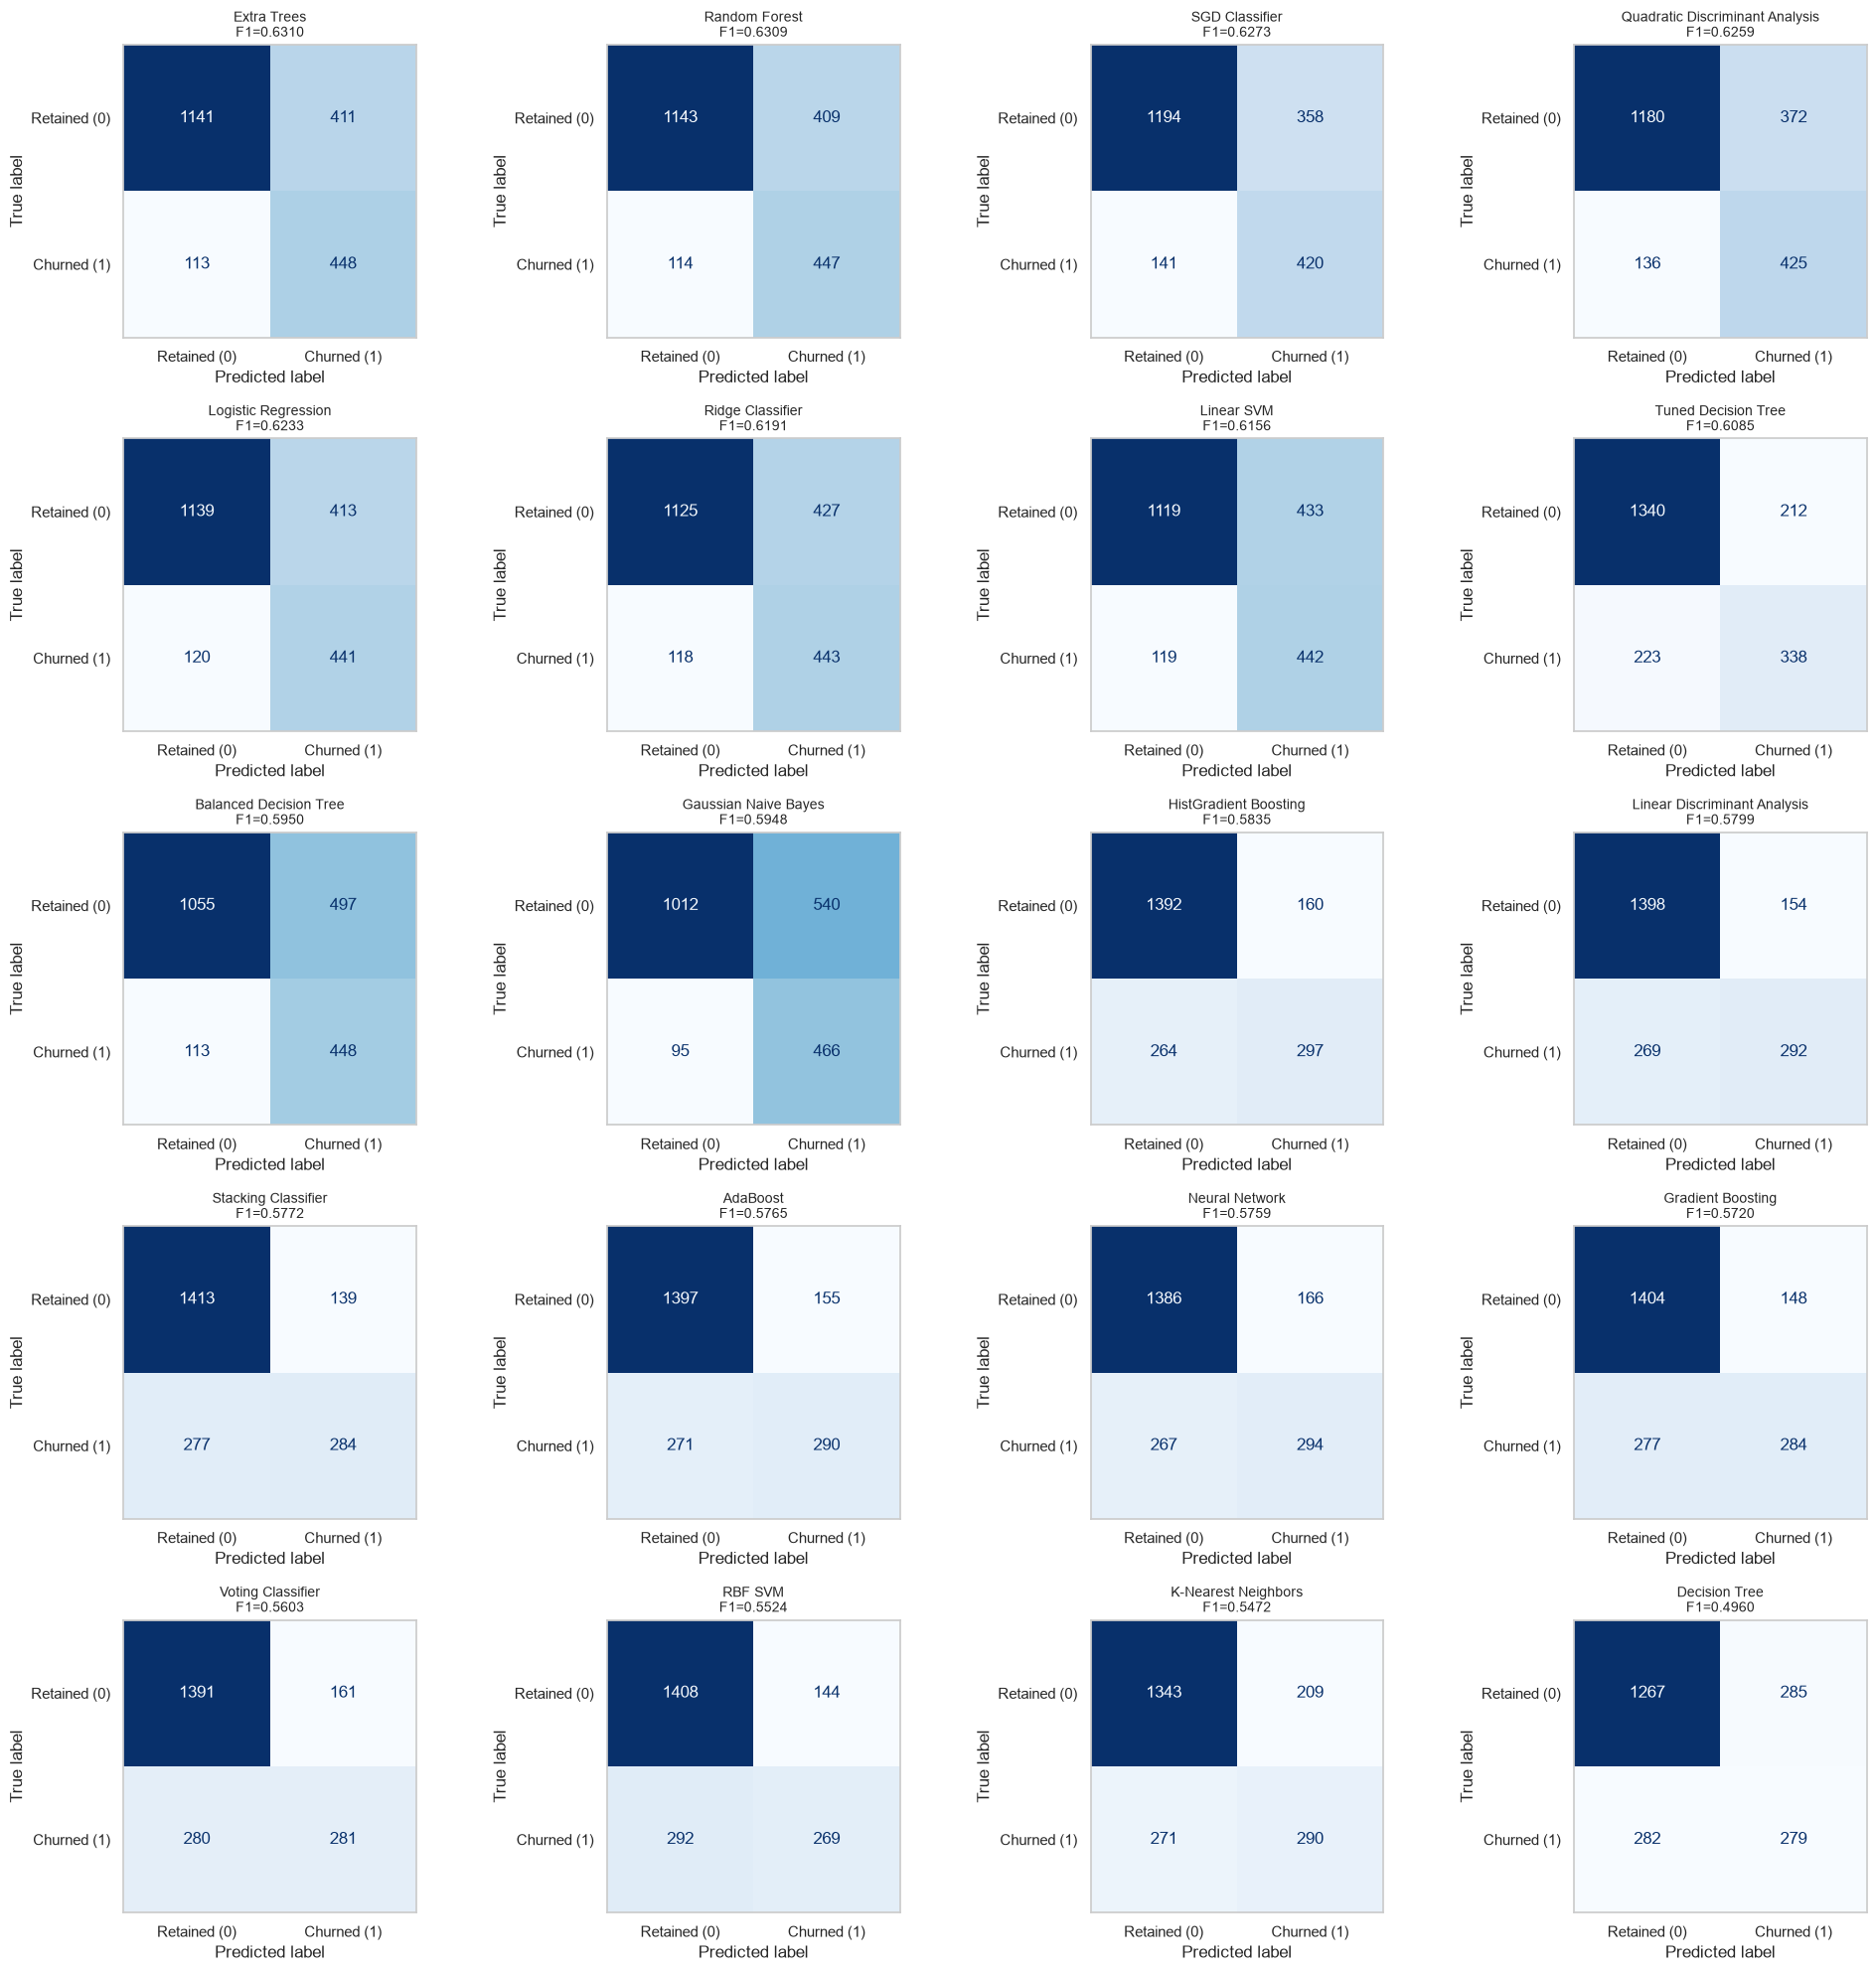

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_models = {**best_models, **decision_tree_models}

n_models = len(all_models)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))

sorted_all_models = results_df.index.tolist()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, name in zip(axes, sorted_all_models):
    model = all_models[name]
    y_pred_model = model.predict(X_test)
    cm_model = confusion_matrix(Y_test, y_pred_model)
    disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model, display_labels=['Retained (0)', 'Churned (1)'])
    disp_model.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{name}\nF1={results_df.loc[name, 'F1 Score']:.4f}", fontsize=10)
    ax.grid(False)

for ax in axes[len(sorted_all_models):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Model Results (Sorted by Test F1)

| Model | CV F1 | Best Params | Precision | Recall | F1 Score | Accuracy |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Extra Trees** | 0.6227 | `class_weight`: 'balanced' | 0.5215 | 0.7986 | **0.6310** | 0.7520 |
| **Random Forest** | 0.6240 | `class_weight`: 'balanced' | 0.5222 | 0.7968 | **0.6309** | 0.7525 |
| **SGD Classifier** | 0.6356 | `alpha`: 0.001, `class_weight`: 'balanced' | 0.5398 | 0.7487 | **0.6273** | 0.7638 |
| **Quadratic Discriminant Analysis (QDA)** | 0.6290 | `reg_param`: 0.3 | 0.5333 | 0.7576 | **0.6259** | 0.7596 |
| **Logistic Regression** | 0.6319 | `C`: 0.01, `class_weight`: 'balanced' | 0.5164 | 0.7861 | **0.6233** | 0.7478 |
| **Ridge Classifier** | 0.6287 | `alpha`: 10.0, `class_weight`: 'balanced' | 0.5092 | 0.7897 | **0.6191** | 0.7421 |
| **Linear SVM** | 0.6307 | `C`: 1, `class_weight`: 'balanced' | 0.5051 | 0.7879 | **0.6156** | 0.7388 |
| **Tuned Decision Tree** | 0.5678 | `max_depth`: 5 | 0.6145 | 0.6025 | **0.6085** | 0.7941 |
| **Balanced Decision Tree** | N/A | N/A | 0.4741 | 0.7986 | **0.5950** | 0.7113 |
| **Gaussian Naive Bayes** | 0.6016 | `var_smoothing`: 1e-09 | 0.4632 | 0.8307 | **0.5948** | 0.6995 |
| **HistGradient Boosting** | 0.5925 | `l2_regularization`: 1.0 | 0.6499 | 0.5294 | **0.5835** | 0.7993 |
| **Linear Discriminant Analysis (LDA)** | 0.5842 | `solver`: 'svd' | 0.6547 | 0.5205 | **0.5799** | 0.7998 |
| **Stacking Classifier** | 0.5911 | `final_estimator__C`: 10 | 0.6714 | 0.5062 | **0.5772** | 0.8031 |
| **AdaBoost** | 0.5960 | `learning_rate`: 1.0 | 0.6517 | 0.5169 | **0.5765** | 0.7984 |
| **Neural Network (MLP)** | 0.5908 | `alpha`: 0.001 | 0.6391 | 0.5241 | **0.5759** | 0.7951 |
| **Gradient Boosting** | 0.5964 | `learning_rate`: 0.1 | 0.6574 | 0.5062 | **0.5720** | 0.7989 |
| **Voting Classifier** | 0.5929 | Multiple weak learners tuned | 0.6357 | 0.5009 | **0.5603** | 0.7913 |
| **RBF SVM** | 0.5733 | `C`: 10, `gamma`: 'auto' | 0.6513 | 0.4795 | **0.5524** | 0.7937 |
| **K-Nearest Neighbors (KNN)** | 0.5796 | `n_neighbors`: 9 | 0.5812 | 0.5169 | **0.5472** | 0.7728 |
| **Baseline Decision Tree** | N/A | N/A | 0.4947 | 0.4973 | **0.4960** | 0.7317 |



### Quick Takeaways

* **Top performers:** Extra Trees and Random Forest hit the best F1 (~0.631) and catch ~80% of churners.
* **Linear models were solid:** SGD, Logistic Regression, and Ridge hovered right around ~0.62 F1 without complex tuning.
* **Stacking plays it safe:** Highest overall accuracy (80.3%) and precision (67.1%), but it misses almost half the churners.
* **Naive Bayes is too aggressive:** Highest recall (83.1%), but lots of false alarms (precision is under 47%).
* **Untuned trees flop:** Default decision tree came in dead last (0.496 F1). Balancing and depth limits were necessary.



### Which one to pick?

* **Catch maximum churners:** Use **Extra Trees** or **Random Forest**.
* **Save retention budget:** Use **Stacking** to target only high-confidence leads.

### Detailed Anlysis
* **Top Performers (Extra Trees & Random Forest):** Both Extra Trees and Random Forest lead the pack with nearly identical F1 scores (~0.631). By using balanced class weighting, they successfully catch about 80% of actual churners (Recall ~0.798) while keeping precision around 52%.
* **Linear Models are Remarkably Strong:** Models like SGD, Logistic Regression, Linear SVM, and Ridge Classifier sit right behind the ensemble tree models (F1 values between 0.619 and 0.627). This suggests the decision boundary is mostly linear, so simple linear techniques get you almost all the way there.
* **Trade-offs with Boosting & Stacking:** The Stacking Classifier hit the highest overall Accuracy (80.3%) and Precision (67.1%), but its Recall dropped sharply to 50.6%. Gradient Boosting and AdaBoost follow the exact same pattern—good at avoiding false alarms, but they miss roughly half of the customers who actually leave.
* **Naive Bayes Catches the Most Churners:** Gaussian Naive Bayes posted the single highest Recall score (83.1%), but its Precision was weak (46.3%), leading to a lower F1 score overall. It's aggressive, but it throws off too many false positives.
* **Decision Trees Need Tuning:** The raw baseline Decision Tree ended up at the bottom (F1 = 0.4960). Setting class weights or pruning parameters via hyperparameter tuning improved performance significantly (pushing F1 above 0.60).

### Impact of Feature Engineering

Additional features such as `CustomerType` and `Support_Count` were created to capture customer lifecycle stage and service adoption behavior. The updated models showed only minor changes in performance compared to the baseline models.

This suggests that the original dataset already contained strong predictors of churn, particularly Contract Type, Payment Method, Internet Service, Tech Support, Online Security, tenure, and Monthly Charges. While the engineered features improved the business interpretability of the dataset, they resulted in only marginal improvements to predictive performance.

Overall, feature engineering neither significantly improved nor degraded model quality, indicating that the original features already captured most of the churn signal present in the data.